In [1]:
!pip install gf180mcu --upgrade
!pip install gdsfactory --upgrade
!pip install ihp-gdsfactory --upgrade

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.6/90.6 kB 1.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.4/62.4 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 350.2/350.2 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 779.6/779.6 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.8/252.8 kB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 463.6/463.6 kB 32.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 31.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 57.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 23.6 MB/s eta 0:00:00
   ━━━━━━

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.2/110.2 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 840.3/840.3 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 289.1/289.1 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.6/472.6 kB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.1/123.1 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 630.9/630.9 kB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.7/608.7 kB 36.2 MB/s eta 0:00:00
  Attempting uninstall: pydantic-core
    Found existing installation: pydantic_core 2.41.5
    Uninstalling pydantic_core-2.41.5:
      Successfully uninstalled pydantic_core-2.41.5
  Attempting uninstall: decorator
    Found existing installation: decorator 4.4.2
    Uninstalling decorator-4.4.2:
      Successfully uninstalled decorator-4.4.2
  Attempti

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.5/41.5 kB 1.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of gdsfactoryplus to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of gdsfactoryplus to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
INFO: pip is looking at multiple versions of doroutes to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of doroutes to determine which version is compatible with other requirements. This could take a while.
  Preparing metadata (setup.py) .

In [2]:
from __future__ import annotations

__all__ = ["resistance_meander"]

import numpy as np

import gdsfactory as gf
import gf180mcu
#import ihp

from gdsfactory.component import Component
from gdsfactory.typings import LayerSpec, Size

gf180mcu.PDK.activate()
#ihp.PDK.activate()

print("PDK is activated.")

PDK is activated.


The following patch is due to `gf180mcu.cells.via_stack` issue as reported in https://github.com/gdsfactory/gf180mcu/issues/30 which is not resolved and merged into upstream repository.  It also contains patch for `metal_level > 2`

In [3]:
"""
Complete Metal1..Metal5 via-stack generator for GF180MCU, built with
gdsfactory primitives only (does not depend on gf180mcu.cells.via_stack,
which only implements up to Metal2 in the currently installed package).

Design-rule values (from GF180MCU Design Manual):
  - CO.1  : contact size            0.22 um
  - Vn.1  : via size (Via1..Via5)   0.26 um
  - Vn.2a : via spacing             0.26 um
  - Vn.3/Vn.4 : metal enclosure of via   0.06 um per side
Layer GDS numbers (drm_04_1):
  Contact=33, Metal1=34, Via1=35, Metal2=36, Via2=38,
  Metal3=42, Via3=40, Metal4=46, Via4=41, Metal5=81, Via5=82.
"""

#import gdsfactory as gf

LAYER_STACK = {
    1: {"metal": (34, 0), "via": (35, 0)},  # Metal1, Via1 (Metal1<->Metal2)
    2: {"metal": (36, 0), "via": (38, 0)},  # Metal2, Via2 (Metal2<->Metal3)
    3: {"metal": (42, 0), "via": (40, 0)},  # Metal3, Via3 (Metal3<->Metal4)
    4: {"metal": (46, 0), "via": (41, 0)},  # Metal4, Via4 (Metal4<->Metal5)
    5: {"metal": (81, 0), "via": (82, 0)},  # Metal5, Via5 (Metal5<->MetalTop)
}
CONTACT_LAYER = (33, 0)


def _via_array(c, xmin, xmax, ymin, ymax, via_size, via_spacing, layer):
    """Fills the given bbox with a centered array of via/contact squares.

    Returns the actual bbox occupied by the placed array (xmin, xmax, ymin, ymax),
    which may be smaller than the requested bbox if the pitch doesn't divide evenly.
    """
    vw, vh = via_size
    sx, sy = via_spacing
    pitch_x, pitch_y = vw + sx, vh + sy
    width, height = xmax - xmin, ymax - ymin
    nx = max(1, int((width + sx) // pitch_x))
    ny = max(1, int((height + sy) // pitch_y))
    used_w = nx * vw + (nx - 1) * sx
    used_h = ny * vh + (ny - 1) * sy
    x0 = xmin + (width - used_w) / 2
    y0 = ymin + (height - used_h) / 2
    for i in range(nx):
        for j in range(ny):
            v = c.add_ref(gf.components.rectangle(size=(vw, vh), layer=layer))
            v.move((x0 + i * pitch_x, y0 + j * pitch_y))
    return x0, x0 + used_w, y0, y0 + used_h


def via_stack_full(
    x_range=(0, 1),
    y_range=(0, 1),
    metal_level=5,
    con_size=(0.22, 0.22),
    con_enc=0.07,
    m_enc=0.06,
    con_spacing=(0.28, 0.28),
    via_size=(0.26, 0.26),
    via_spacing=(0.26, 0.26),
    via_enc=(0.06, 0.06),
):
    """Returns a GF180MCU via stack from Metal1 up to Metal(metal_level).

    Args:
        x_range: (xmin, xmax) footprint of the contact/via array, in um.
        y_range: (ymin, ymax) footprint of the contact/via array, in um.
        metal_level: top metal level to stack up to (1-5).
        con_size: contact size (w, h).
        con_enc: metal1 enclosure of contact (scalar, matches gf180mcu default).
        m_enc: metal enclosure of via, one side (scalar, matches gf180mcu default).
        con_spacing: contact-to-contact spacing (w, h).
        via_size: via size (w, h), same for Via1..Via5 in GF180MCU.
        via_spacing: via-to-via spacing (w, h).
        via_enc: (x, y) via enclosure used when clamping intermediate metal size.

    metal_level 1: contact + Metal1 only.
    metal_level 2: + Via1 + Metal2.
    metal_level 3: + Via2 + Metal3.
    metal_level 4: + Via3 + Metal4.
    metal_level 5: + Via4 + Metal5.
    """
    assert 1 <= metal_level <= 5, "metal_level must be between 1 and 5"

    c = gf.Component()

    x0, x1 = x_range
    y0, y1 = y_range

    # --- Level 1: contact array + Metal1 ---
    c_xmin, c_xmax, c_ymin, c_ymax = _via_array(
        c, x0, x1, y0, y1, con_size, con_spacing, CONTACT_LAYER
    )

    m_x = (c_xmax - c_xmin) + 2 * m_enc
    m_y = (c_ymax - c_ymin) + 2 * m_enc
    m_xmin = c_xmin - m_enc
    m_ymin = c_ymin - m_enc
    c.add_ref(
        gf.components.rectangle(size=(m_x, m_y), layer=LAYER_STACK[1]["metal"])
    ).move((m_xmin, m_ymin))
    m_xmax, m_ymax = m_xmin + m_x, m_ymin + m_y

    # --- Levels 2..metal_level: Via(n-1) array + Metal(n) ---
    for level in range(2, metal_level + 1):
        via_layer = LAYER_STACK[level - 1]["via"]
        via_xmin, via_xmax, via_ymin, via_ymax = _via_array(
            c, m_xmin, m_xmax, m_ymin, m_ymax, via_size, via_spacing, via_layer
        )
        via_w = via_xmax - via_xmin
        via_h = via_ymax - via_ymin

        is_last = level == metal_level
        min_x = via_size[0] + 2 * via_enc[0]
        min_y = via_size[1] + 2 * via_enc[1]

        next_x = via_w + 2 * m_enc
        next_y = via_h + 2 * m_enc
        if not is_last:
            # Not the top level yet: make sure this metal is big enough to
            # host the enclosure of the *next* via above it too.
            next_x = max(next_x, min_x)
            next_y = max(next_y, min_y)

        mx = (next_x - via_w) / 2
        my = (next_y - via_h) / 2
        new_xmin, new_ymin = via_xmin - mx, via_ymin - my

        c.add_ref(
            gf.components.rectangle(
                size=(next_x, next_y), layer=LAYER_STACK[level]["metal"]
            )
        ).move((new_xmin, new_ymin))

        m_xmin, m_ymin = new_xmin, new_ymin
        m_xmax, m_ymax = new_xmin + next_x, new_ymin + next_y

    # --- Ports on bottom (e1) and top (e2) metal ---
    c.add_port(
        name="e1",
        center=((x0 + x1) / 2, (y0 + y1) / 2),
        width=m_x,
        orientation=0,
        layer=LAYER_STACK[1]["metal"],
        port_type="electrical",
    )
    c.add_port(
        name="e2",
        center=((x0 + x1) / 2, (y0 + y1) / 2),
        width=m_xmax - m_xmin,
        orientation=0,
        layer=LAYER_STACK[metal_level]["metal"],
        port_type="electrical",
    )
    return c

In [4]:
#@gf.cell_with_module_name
def antenna(
    hooks: int = 4,
    finger_length: float = 30.0,
    finger_width: float = 2.0,
    finger_gap_vertical: float = 2.0,
    finger_gap_horizontal: float = 2.0,
    feed_width: float = 10.0,
    feed_length: float = 30.0,
    layer_metal: LayerSpec = (1, 0),
    port_type: str = "electrical",
) -> Component:
    c = Component()

    # Hook has two fingers (*2) and there are up and down hooks (*2) divided by middle divisor that takes space 2 fingers (+2)
    # When looping the hook connectors and fingers we remove one middle connector finger. There is odd number of fingers counted total, when the middle connector has one finger.s

    fingers = hooks * 2 * 2 + 2
    middle_connector_height = finger_width * 2
    size_box = (finger_width, finger_width)

    # Calculate total dimensions
    total_width = finger_length + finger_gap_horizontal
    total_height = fingers * finger_width + (fingers - 1) * finger_gap_vertical

    # Create left side base column for up and down connectors
    left_base = gf.components.rectangle(
        size=(finger_width, total_height - middle_connector_height),
        layer=layer_metal,
    )
    left_base_ref = c.add_ref(left_base)
    left_base_ref.move((-total_width / 2 - finger_width, -total_height / 2 + middle_connector_height))

    # Create middle divisor connectors
    short_left_middle_base = gf.components.rectangle(
        size=size_box,
        layer=layer_metal,
    )
    short_left_middle_base_ref = c.add_ref(short_left_middle_base)
    short_left_middle_base_ref.move((-total_width / 2 , -total_height / 2 + finger_width*fingers))

    # Loop hook connectors for up and down sections, -1 removes the middle connector
    for i in range(int(fingers/2)-1):
        if i %2 == 0:
            # Create short left down attacher
            short_left_base = gf.components.rectangle(
                size=size_box,
                layer=layer_metal,
            )
            short_left_base_ref = c.add_ref(short_left_base)
            short_left_base_ref.move((-total_width / 2 + finger_width,
                                      -total_height / 2 + finger_width * fingers - finger_width * 3 - finger_width * 2 * i))

            # Create short right down attacher
            short_right_base = gf.components.rectangle(
                size=size_box,
                layer=layer_metal,
            )
            short_right_base_ref = c.add_ref(short_right_base)
            short_right_base_ref.move((total_width / 2 - finger_width ,
                                       -total_height / 2 + finger_width * fingers - finger_width - finger_width * 2 * i))
        else:
            # Create short left up attacher
            short_left_base = gf.components.rectangle(
                size=size_box,
                layer=layer_metal,
            )
            short_left_base_ref = c.add_ref(short_left_base)
            short_left_base_ref.move((-total_width / 2 + finger_width,
                                      -total_height / 2 + finger_width * fingers + finger_width + finger_width * 2 * i))

            # Create short right up attacher
            short_right_base = gf.components.rectangle(
                size=size_box,
                layer=layer_metal,
            )
            short_right_base_ref = c.add_ref(short_right_base)
            short_right_base_ref.move((total_width / 2 - finger_width ,
                                       -total_height / 2 + finger_width * fingers - finger_width + finger_width * 2 * i))

    # Create interdigital fingers
    for i in range(fingers-1):
        left_finger = gf.components.rectangle(
            size=(finger_length, finger_width),
            layer=layer_metal,
        )
        left_finger_ref = c.add_ref(left_finger)

        # We start from a left finger
        x_pos = -finger_length / 2 + (-1) ** (0) * finger_gap_horizontal / 2
        y_pos = (
            total_height / 2 - finger_width - i * (finger_width + finger_gap_vertical)
        )
        left_finger_ref.move((x_pos, y_pos))

     # Add ports
    c.add_port(
        name="up",
        center=(-total_width / 2 - finger_width/2, total_height / 2),
        width=feed_width,
        orientation=90,
        layer=layer_metal,
        port_type=port_type,
    )

    c.add_port(
        name="down",
        center=(-total_width / 2 - finger_width/2, -total_height / 2 + finger_width * 2),
        width=feed_width,
        orientation=-90,
        layer=layer_metal,
        port_type=port_type,
    )


    # Add metadata
    c.info["coupler_type"] = "interdigital"
    c.info["fingers"] = fingers
    c.info["finger_length"] = finger_length
    c.info["finger_width"] = finger_width
    c.info["finger_gap_horizontal"] = finger_gap_horizontal
    c.info["finger_gap_vertical"] = finger_gap_vertical

    return c

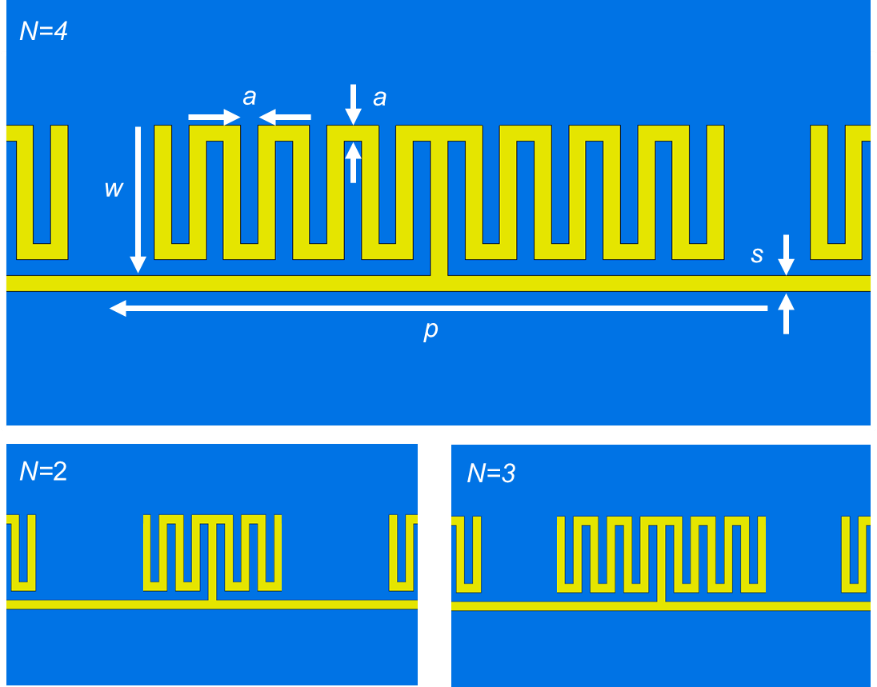

In [5]:
# Selection between GF180MCU and IHP-SG13G2 PDKs
USE_IHP_SG13G2 = 1

# Layers definition
# https://gf180mcu-pdk.readthedocs.io/en/latest/physical_verification/design_manual/drm_04_1.html


['via_generator', 'via_stack']
(25.0, 200.0)


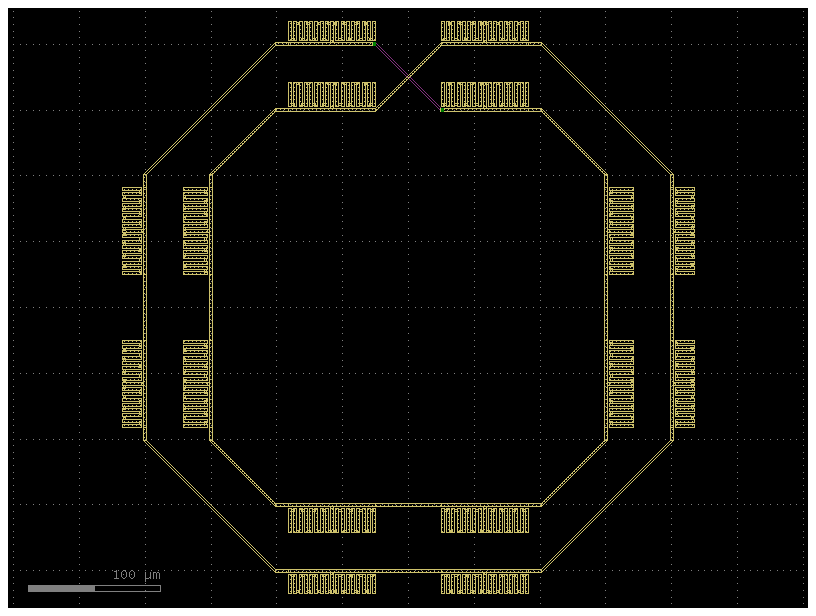

In [8]:
c = gf.Component()
all_components = []

def cycle(c, finger_length, spacing, middle_length):
    rotations = [0,90,180,270]
    positions = [(-middle_length/2,spacing), (-spacing,-middle_length/2), (middle_length/2,-spacing), (spacing,middle_length/2)]
    components = []

    """
    t1 and t2 are length extensions from the main RF component.
    Otherwise the diagonal connection would start from the RF component itself.
    t1 length should be calculated to be exact as the middle connector's length.
    Now length is 10. t1 connects to the first RF up port  and t2 connects to the second RF down port.
    """
    for i in range(4):
        ant1_inner = c << antenna(hooks=4, finger_length=finger_length, finger_width=2, finger_gap_vertical=2, finger_gap_horizontal=2, feed_width=2, feed_length=30, layer_metal=(81, 0), port_type='electrical')
        ant2_inner = c << antenna(hooks=4, finger_length=finger_length, finger_width=2, finger_gap_vertical=2, finger_gap_horizontal=2, feed_width=2, feed_length=30, layer_metal=(81, 0), port_type='electrical')
        middle_separator1_inner = c << gf.components.taper(length=middle_length, width1=2, with_two_ports=True, cross_section='metal5', port_names=('o1', 'o2'), layer=(81,0), port_types=('electrical', 'electrical'))
        ant1_inner.connect("down", middle_separator1_inner.ports["o1"])
        ant2_inner.connect("up", middle_separator1_inner.ports["o2"])
        t1 = c << gf.components.taper(length=10, width1=2, with_two_ports=True, cross_section='metal5', port_names=('o1', 'o2'), layer=(81,0), port_types=('electrical', 'electrical'), with_bbox=True)
        t2 = c << gf.components.taper(length=10, width1=2, with_two_ports=True, cross_section='metal5', port_names=('o1', 'o2'), layer=(81,0), port_types=('electrical', 'electrical'), with_bbox=True)
        t1.connect("o1", ant1_inner.ports["up"])
        t2.connect("o1", ant2_inner.ports["down"])
        components_list = [ant1_inner,ant2_inner,middle_separator1_inner,t1,t2]

        for component in components_list:
            component.rotate(rotations[i])
            component.dmove(positions[i])

        components.append(components_list)

    for i in range(0,4,2):
        route = gf.routing.route_quad(
            c,
            port1=components[i][4].ports["o2"],
            port2=components[4-i-1][3].ports["o2"],
            layer=(81, 0),
            )
        route = gf.routing.route_quad(
            c,
            port1=components[i][3].ports["o2"],
            port2=components[i+1][4].ports["o2"],
            layer=(81, 0),
            )
    all_components.append(components)
    return c

# Inner loop with longer electrical lengths
middle_length = 50
spacing = 150
finger_length = 2*9
c = cycle(c, finger_length, spacing, middle_length)

# Outer loop with shorter electrical lengths
spacing = 200
finger_length = 2*7
c = cycle(c, finger_length, spacing, middle_length)

# Component indexes [0] inner circle, [0] top part, [2] middle_separator1_inner port o1
# Is routed to
# Component indexes [1] outer circle, [0] top part, [2] middle_separator1_inner port o2
# 3rd index numbers are from components_list = [ant1_inner,ant2_inner,middle_separator1_inner,t1,t2]

route = gf.routing.route_quad(
    c,
    port1=all_components[0][0][2].ports["o1"],
    port2=all_components[1][0][2].ports["o2"],
    layer=(81, 0),
    )

# 2. Define the Overpass CrossSection (Layer 2)

## TS: Testataan quad reittiä täältä: https://gdsfactory.github.io/gdsfactory/notebooks/04_routing_electrical.html

#xs_jumper = gf.cross_section.cross_section(layer=(46, 0), width=1.0)

jumper_route_points = [all_components[0][0][2].ports["o2"].center, all_components[1][0][2].ports["o1"].center]


# 3. Create a Path manually between the two via centers
# This bypasses the PortLayerMismatchError of the router
#p = gf.path.Path(jumper_route_points)

# 4. Extrude the path and add it to the component
#jumper_bridge = p.extrude(xs_jumper)
#c << jumper_bridge
jumper = gf.routing.route_quad(c, all_components[0][0][2].ports["o2"], all_components[1][0][2].ports["o1"], layer=(46, 0))

# 5.  Create overlapping areas between the two layers for the via_stack to actually work
via_layers_overlap_length = 2
x1, y1 = all_components[1][0][2].ports["o1"].center
x2, y2 = all_components[0][0][2].ports["o2"].center
v1 = c << gf.components.taper(length=via_layers_overlap_length, width1=2, with_two_ports=True, cross_section='metal5', port_names=('o1', 'o2'), layer=(81,0), port_types=('electrical', 'electrical'), with_bbox=True)
v1.move((x1-via_layers_overlap_length, y1))
v2 = c << gf.components.taper(length=via_layers_overlap_length, width1=2, with_two_ports=True, cross_section='metal5', port_names=('o1', 'o2'), layer=(81,0), port_types=('electrical', 'electrical'), with_bbox=True)
v2.move((x2, y2))

# 6. Creates array of vias between metal5 layer (81, 0) and metal4 layer (46, 0)
# see layer information in https://gf180mcu-pdk.readthedocs.io/en/latest/physical_verification/design_manual/drm_04_1.html
# and https://gdsfactory.github.io/gdsfactory/notebooks/03_layer_stack.html
print([name for name in dir(gf180mcu.cells) if "via" in name.lower()])
#via_instance = gf180mcu.cells.via_stack(size=(5.0, 5.0))
via_instance = via_stack_full(
    x_range=(0, 1),
    y_range=(0, 1),
    metal_level=5
)

#print(type(all_components[0][0][2].ports["o2"].center))
print(all_components[1][0][2].ports["o2"].center)
#print(gf.__version__)

# 7. Add the via to the layout canvas
#via_ref = c.add_ref(via_instance)
via_ref_1 = c.add_ref(
    via_instance,
    columns=via_layers_overlap_length,
    rows=via_layers_overlap_length,
    column_pitch=1.0,
    row_pitch=1.0,
)
via_ref_1.move((x1-via_layers_overlap_length, y1-via_layers_overlap_length/2))

via_ref_2 = c.add_ref(
    via_instance,
    columns=via_layers_overlap_length,
    rows=via_layers_overlap_length,
    column_pitch=1.0,
    row_pitch=1.0,
)
via_ref_2.move((x2, y2-via_layers_overlap_length/2))


##### do we need the following remove() operations ?  #####
"""
Explanation by Tuomas Sorakivi:
There is the middle separator as component to get the position calculation right between the antennas.
The positions are set based on the middle separator in the cross area.
Then the middle separator is removed, so it's just to calculate the positions there in the code.

First we add all identical loops without the crossing to have the exact same distances.
Then we add the cross jumper and remove the middle part from the top loops.
Another way to do it would be to set the x and y positions but in this case it's not necessary because
the components are aligned automatically.

Without these 2 remove operations, the top parts would have the middle connector.
"""
c.insts.remove(all_components[0][0][2])
c.insts.remove(all_components[1][0][2])

c.draw_ports()

c.write_gds("RTWO.gds")  # write it to a GDS file. You can open it in klayout.
c.show()  # show it in klayout
c.plot()  # plot it in jupyter notebook

Some annotation for illustration purposes :

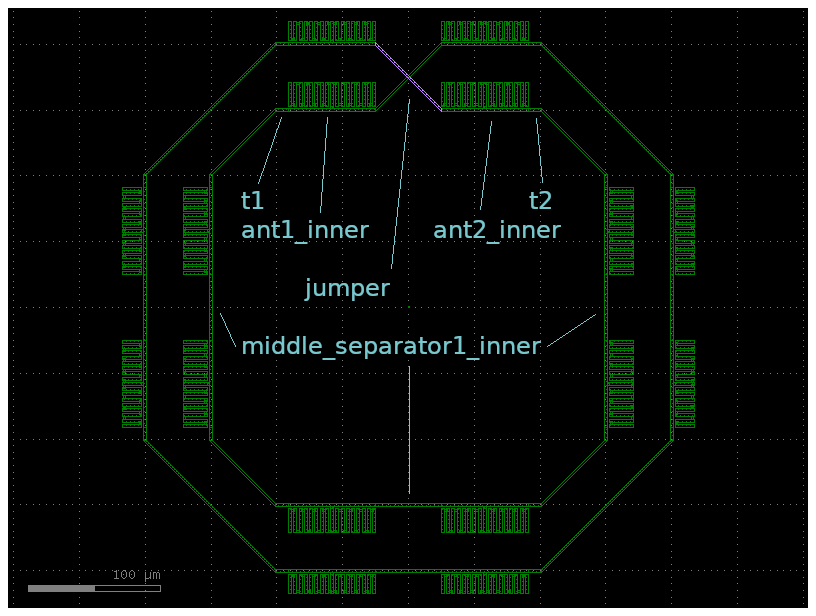